Band structure on (stiffness, k)-space (elastic load)

C:\Users\20324\AppData\Local\Temp\ipykernel_18440\1776745221.py:54: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes.scatter(kList, sList, data_flat[i], cmap="jet", marker="o",s=1, alpha=0.9)


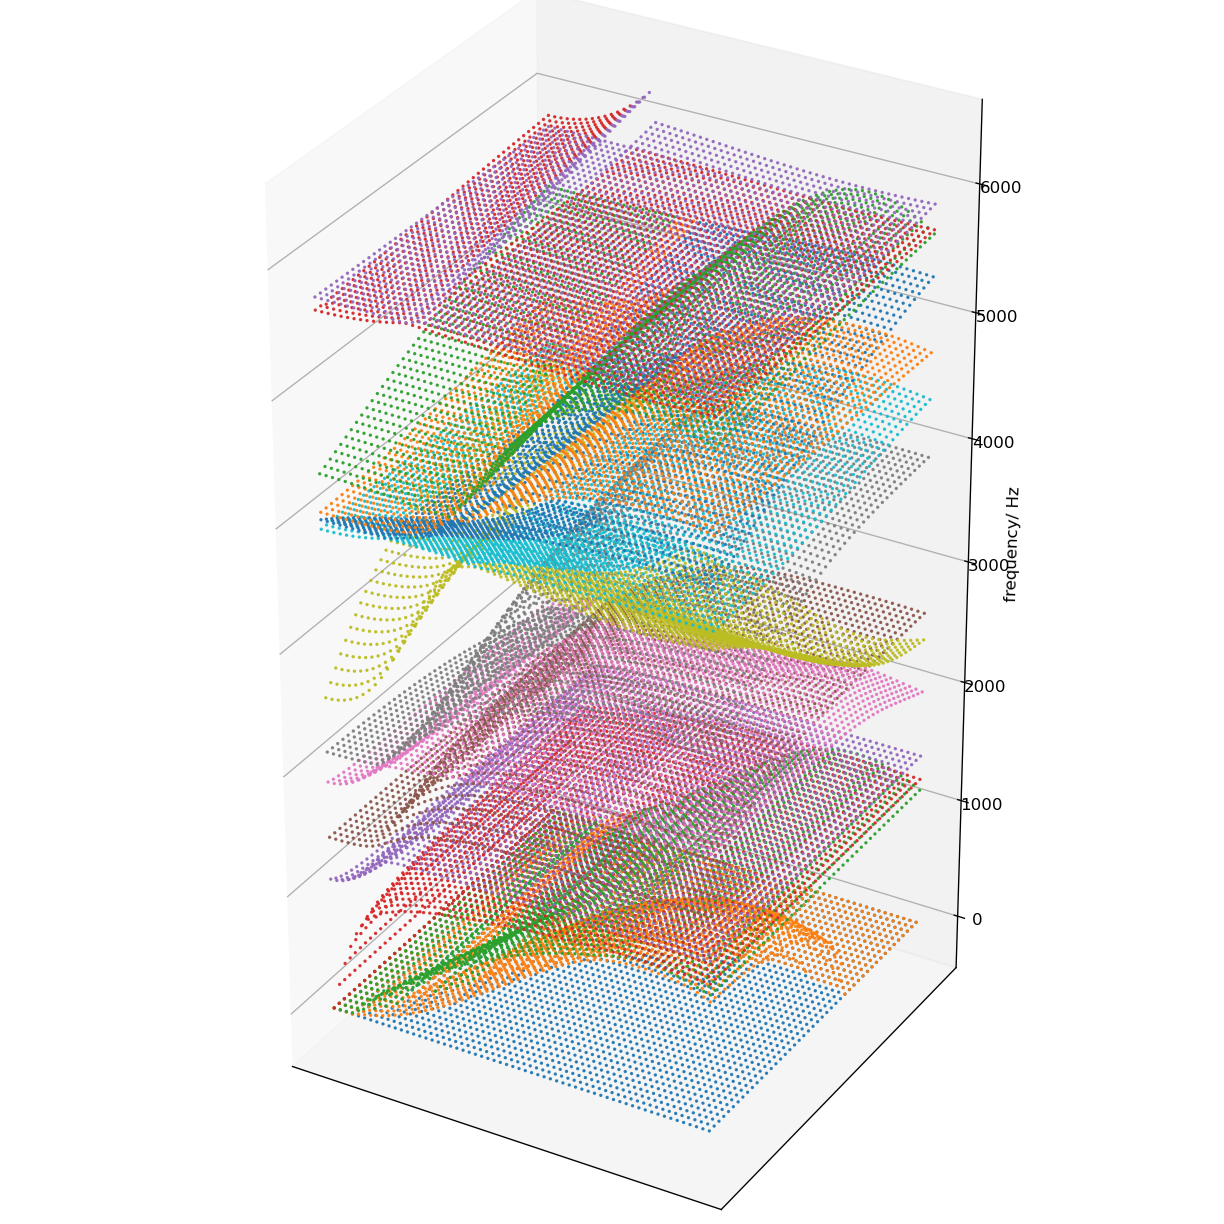

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as ticker
import copy

a=0.012
bands_to_show=15
filename="elastic_load"
sspace=10**np.arange(1,10.1,0.2)         #Contact stiffness list

with open('w(k)_%s.txt'%filename,'rt') as raw_data:
    data=np.loadtxt(raw_data,delimiter=',',skiprows=8).T
num_s=len(sspace)
num_k=int(data.shape[1]/num_s)
kspace=data[0,:num_k]
data=np.array(data[1:])
num_bands=len(data)
data=np.reshape(data,(num_bands,num_s,num_k))
data.shape
bands_to_show=min(num_bands,bands_to_show)


#sorting based on continuity
dataReorder=copy.deepcopy(data)
def closest(list, target):
    a=[]
    for i in list:
        a.append(abs(target-i))
    return a.index(min(a))
for i in range(num_bands):
    for k in range(num_k):
        for s in range(2,num_s):
            position=closest([data[i][s][k] for i in range(num_bands)], 2*dataReorder[i][s-1][k]-dataReorder[i][s-2][k])
            dataReorder[i][s][k]=data[position][s][k]
            data[position][s][k]=1e18


#build ploting data
kList=np.tile(kspace,num_s)
sList=np.log10(np.repeat(sspace,num_k))
data_flat=[[] for i in range(num_bands)]
for i in range(num_bands):
    data_flat[i]=dataReorder[i].flatten()

###Plot the result###
plt.rcParams['figure.figsize'] = (10,30)
fig=plt.figure(dpi=120)
axes=fig.add_axes(Axes3D(fig))
plt.xticks([])
plt.yticks([])
plt.gca().set_box_aspect((1, 1, 2))
for i in range(bands_to_show):
    axes.scatter(kList, sList, data_flat[i], cmap="jet", marker="o",s=1, alpha=0.9)
Max=max(data_flat[bands_to_show-1])
axes.tick_params(axis='z',labelsize=10)
axes.set_zlabel('frequency/ Hz')
plt.show()

np.savetxt("kList_%s.csv"%(filename),np.array(kList),delimiter=',', newline='\n', fmt='%f')
np.savetxt("SList_%s.csv"%(filename),np.array(sList),delimiter=',', newline='\n', fmt='%f')
np.savetxt("freq(s,k)_%s.csv"%(filename),np.array(data_flat[:bands_to_show]),delimiter=',', newline='\n', fmt='%f')

C:\Users\20324\AppData\Local\Temp\ipykernel_18440\3393963804.py:54: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes.scatter(kList, sList, data_flat[i], cmap="jet", marker="o",s=1, alpha=0.9)


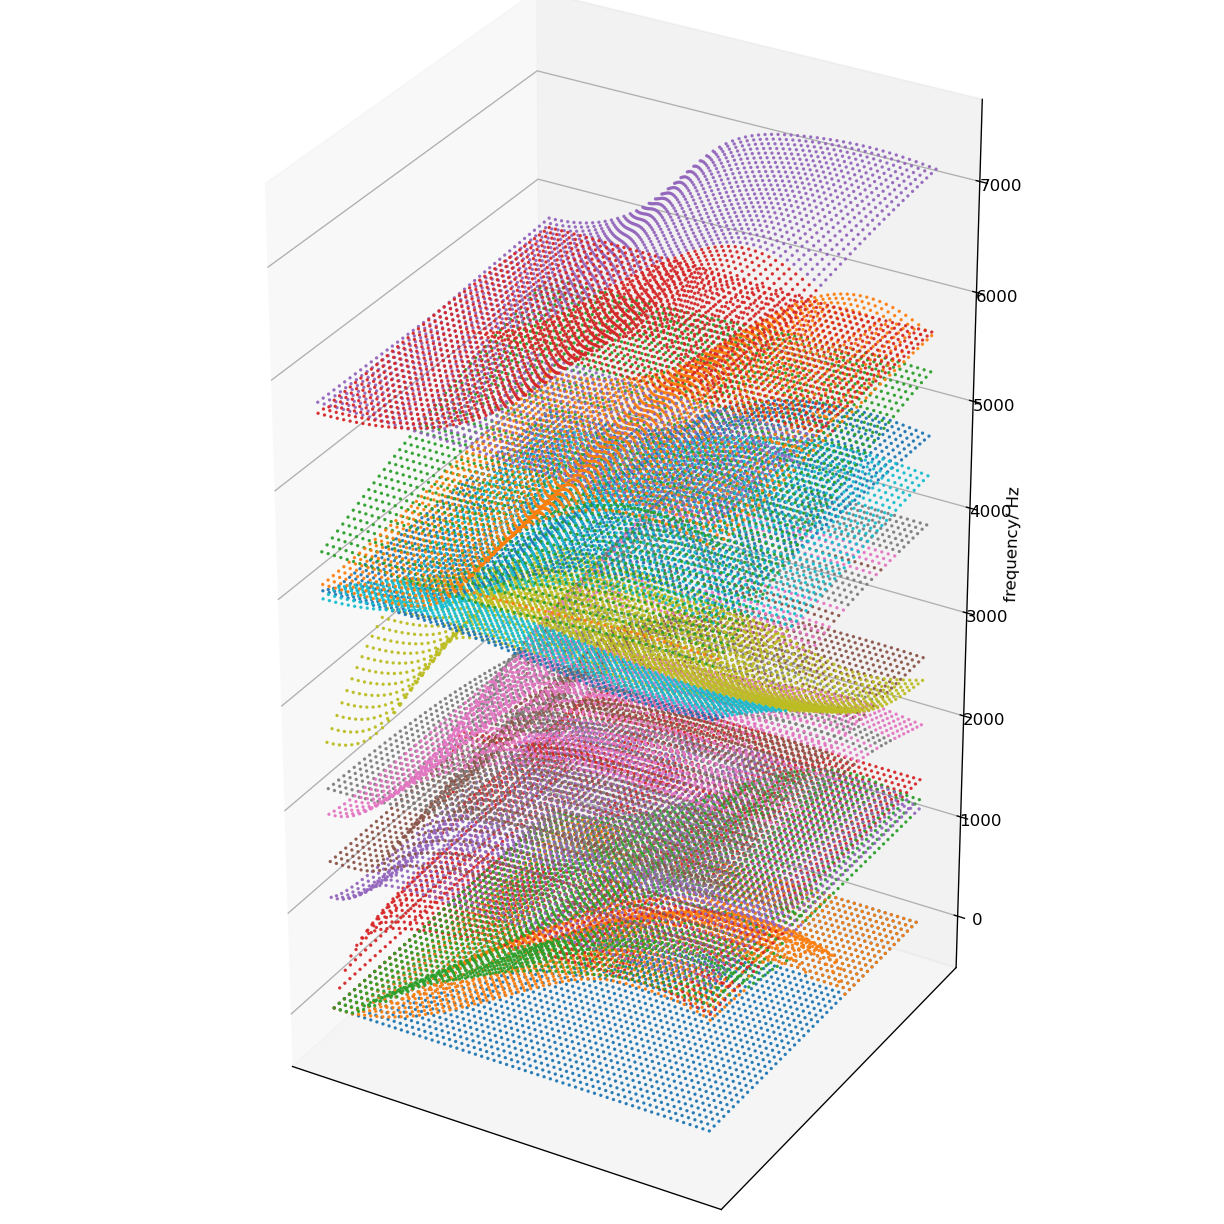

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker as ticker
import copy

a=0.012
bands_to_show=15
filename="elastic_load"
sspace=10**np.arange(1,10.1,0.2)         #Contact stiffness list

with open('w(k)_%s.txt'%filename,'rt') as raw_data:
    data=np.loadtxt(raw_data,delimiter=',',skiprows=8).T
num_s=len(sspace)
num_k=int(data.shape[1]/num_s)
kspace=data[0,:num_k]
data=np.array(data[1:])
num_bands=len(data)
data=np.reshape(data,(num_bands,num_s,num_k))
data.shape
bands_to_show=min(num_bands,bands_to_show)


#sorting based on continuity
dataReorder=copy.deepcopy(data)
def closest(list, target):
    a=[]
    for i in list:
        a.append(abs(target-i))
    return a.index(min(a))
for i in range(num_bands):
    for k in range(2,num_k):
        for s in range(num_s):
            position=closest([data[i][s][k] for i in range(num_bands)], 2*dataReorder[i][s][k-1]-dataReorder[i][s][k-2])
            dataReorder[i][s][k]=data[position][s][k]
            data[position][s][k]=1e18


#build ploting data
kList=np.tile(kspace,num_s)
sList=np.log10(np.repeat(sspace,num_k))
data_flat=[[] for i in range(num_bands)]
for i in range(num_bands):
    data_flat[i]=dataReorder[i].flatten()

###Plot the result###
plt.rcParams['figure.figsize'] = (10,30)
fig=plt.figure(dpi=120)
axes=fig.add_axes(Axes3D(fig))
plt.xticks([])
plt.yticks([])
plt.gca().set_box_aspect((1, 1, 2))
for i in range(bands_to_show):
    axes.scatter(kList, sList, data_flat[i], cmap="jet", marker="o",s=1, alpha=0.9)
Max=max(data_flat[bands_to_show-1])
axes.tick_params(axis='z',labelsize=10)
axes.set_zlabel('frequency/ Hz')
plt.show()

np.savetxt("kList_%s.csv"%(filename),np.array(kList),delimiter=',', newline='\n', fmt='%f')
np.savetxt("SList_%s.csv"%(filename),np.array(sList),delimiter=',', newline='\n', fmt='%f')
np.savetxt("freq(s,k)_%s.csv"%(filename),np.array(data_flat[:bands_to_show]),delimiter=',', newline='\n', fmt='%f')

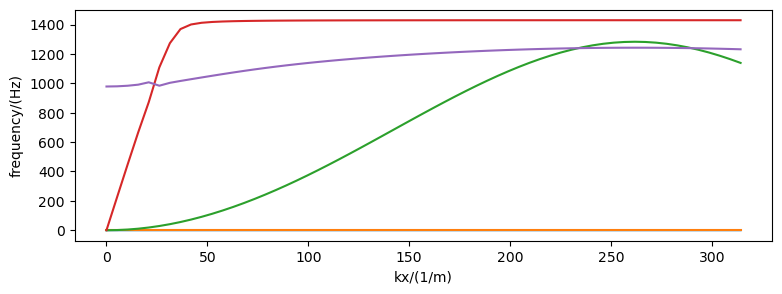

In [40]:
plt.rcParams['figure.figsize'] = (9,3)
for i in [1,0,2,3,4]:
    plt.plot(kspace,dataReorder[i][31])
plt.xlabel("kx/(1/m)")
plt.ylabel("frequency/(Hz)")
plt.show()